# 09 - Mixed Precision Validation

Notebook 08 produced a defensible mixed-precision policy and a GGUF artifact that encodes it.  This notebook validates that artifact end to end: quality, latency, throughput, runtime, memory, and size.

The central question is not whether the mixed model can be built.  Notebook 08 already answered that.  The question here is whether the mixed GGUF keeps enough of the Q4_K_M deployment payoff while avoiding the quality loss predicted by the sensitive-layer evidence.

## 1. Validation Goal

This notebook compares four GGUF artifacts under one llama.cpp-based validation harness:

- FP16 GGUF reference
- Q8_0 GGUF
- Q4_K_M GGUF
- Mixed GGUF from Notebook 08: Q4_K_M default with Q8_0 overrides for protected layers 3, 11, and 26

Primary outputs:

- Full HumanEval pass@1 and passed/total counts
- Per-problem generation latency, TTFT, generated tokens, execution time, and total problem time
- Optional short performance benchmark using fixed prompts
- Artifact size and process RSS snapshots
- A go/no-go style comparison artifact at `results/09_mixed_precision_validation.json`

## 2. Methodology Notes

The strongest quality comparison is GGUF-to-GGUF in the same harness.  Notebook 07's 70.12% baseline remains useful context, but it was produced by a PyTorch ablation harness.  Treat any direct PyTorch-vs-GGUF comparison as secondary.

This notebook is intentionally resumable.  Each model evaluation writes to disk as soon as it completes, so an interrupted run does not discard previous model results.

## 3. Setup

In [31]:
from datetime import datetime, timezone
from pathlib import Path
from IPython.display import Markdown, display
import gc
import hashlib
import json
import os
import statistics
import sys
import time

import matplotlib.pyplot as plt

try:
    import psutil
except ImportError:
    psutil = None

os.environ["TOKENIZERS_PARALLELISM"] = "false"

In [51]:
CWD = Path.cwd().resolve()
if (CWD / "results").exists() and (CWD / "notebooks").exists():
    PROJECT_ROOT = CWD
else:
    PROJECT_ROOT = (CWD / "..").resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

RESULTS_DIR = PROJECT_ROOT / "results"
EXPORTS_DIR = PROJECT_ROOT / "exports"
RESULTS_DIR.mkdir(exist_ok=True)

PTQ05_PATH = RESULTS_DIR / "05_ptq_artifacts_summary.json"
PERF06_PATH = RESULTS_DIR / "06_benchmarking_perf_snapshot.json"
BASELINE07_PATH = RESULTS_DIR / "07_full_baseline_humaneval.json"
POLICY08_PATH = RESULTS_DIR / "08_mixed_precision_policy.json"
VALIDATION09_PATH = RESULTS_DIR / "09_mixed_precision_validation.json"

ITER_LEDGER_JSONL_PATH = RESULTS_DIR / "09_iteration_ledger.jsonl"
ITER_TENSOR_TYPES_DIR = RESULTS_DIR / "09_tensor_types"
ITER_TENSOR_TYPES_DIR.mkdir(exist_ok=True)

MODEL_ID = "deepseek-ai/DeepSeek-Coder-V2-Lite-Instruct"
DATASET_ID = "openai/openai_humaneval"


def env_flag(name: str, default: bool) -> bool:
    raw = os.environ.get(name)
    if raw is None:
        return default
    return raw.strip().lower() in {"1", "true", "yes", "on"}


# Heavy work is opt-in.  Flip these in the notebook or set environment variables before execution.
RUN_FULL_HUMANEVAL = False
RUN_FRESH_PERF_BENCHMARKS = True
REEVALUATE_EXISTING = True
APPEND_ITERATION_LEDGER = True

HUMANEVAL_MODEL_KEYS = ["fp16", "q8_0", "q4_k_m", "mixed"]
PERF_MODEL_KEYS = ["mixed"]
HUMANEVAL_MAX_PROBLEMS = 164

GGUF_N_CTX = 2048
GGUF_N_THREADS = 8
GGUF_N_GPU_LAYERS = -1
GENERATION_MAX_TOKENS = 512
GENERATION_TEMPERATURE = 0.0
EXEC_TIMEOUT_SEC = 10

print(f"Project root: {PROJECT_ROOT}")
print(f"Results directory: {RESULTS_DIR}")
print(f"Run full HumanEval: {RUN_FULL_HUMANEVAL}")
print(f"Run fresh perf benchmarks: {RUN_FRESH_PERF_BENCHMARKS}")
print(f"Reevaluate existing runs: {REEVALUATE_EXISTING}")
print(f"Append iteration ledger: {APPEND_ITERATION_LEDGER}")

Project root: /Users/jarrett/dev/quantization-study
Results directory: /Users/jarrett/dev/quantization-study/results
Run full HumanEval: False
Run fresh perf benchmarks: True
Reevaluate existing runs: True
Append iteration ledger: True


In [33]:
def load_json(path: Path, required: bool = True):
    if path.exists():
        with path.open() as f:
            return json.load(f)
    if required:
        raise FileNotFoundError(f"Missing required artifact: {path}")
    return None


def save_json(path: Path, payload) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w") as f:
        json.dump(payload, f, indent=2)
    print(f"Saved {path}")


def markdown_table(rows, columns):
    if not rows:
        return "_No rows to display._"

    header = "| " + " | ".join(label for _, label in columns) + " |"
    divider = "| " + " | ".join("---" for _ in columns) + " |"
    body = []

    for row in rows:
        values = []
        for key, _ in columns:
            value = row.get(key, "")
            if value is None:
                value = ""
            elif isinstance(value, float):
                value = f"{value:.2f}"
            elif isinstance(value, list):
                value = ", ".join(str(v) for v in value)
            values.append(str(value))
        body.append("| " + " | ".join(values) + " |")

    return "\n".join([header, divider, *body])


def safe_mean(values):
    clean = [value for value in values if value is not None]
    return statistics.mean(clean) if clean else None


def safe_stdev(values):
    clean = [value for value in values if value is not None]
    return statistics.pstdev(clean) if len(clean) > 1 else 0.0 if clean else None


def safe_div(numerator, denominator):
    if numerator is None or denominator in (None, 0):
        return None
    return numerator / denominator


def pct(numerator, denominator):
    ratio = safe_div(numerator, denominator)
    return ratio * 100 if ratio is not None else None


def process_rss_gib():
    if psutil is None:
        return None
    return psutil.Process().memory_info().rss / (1024 ** 3)


def path_size_gib(path):
    path = Path(path)
    if not path.exists():
        return None
    return path.stat().st_size / (1024 ** 3)

def sha256_file(path):
    path = Path(path)
    if not path.exists():
        return None
    digest = hashlib.sha256()
    with path.open("rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


def read_jsonl(path: Path):
    if not path.exists():
        return []
    rows = []
    with path.open() as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            rows.append(json.loads(line))
    return rows


def append_jsonl(path: Path, row):
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("a") as f:
        f.write(json.dumps(row) + "\n")


## 4. Load Artifacts And Model Manifest

In [52]:
ptq05 = load_json(PTQ05_PATH)
perf06 = load_json(PERF06_PATH, required=False)
baseline07 = load_json(BASELINE07_PATH, required=False)
policy08 = load_json(POLICY08_PATH)
validation09 = load_json(VALIDATION09_PATH, required=False)

if validation09 is None:
    validation09 = {
        "timestamp_utc": datetime.now(timezone.utc).isoformat(),
        "updated_at_utc": datetime.now(timezone.utc).isoformat(),
        "notebook": "09_mixed_precision_validation",
        "model_id": MODEL_ID,
        "dataset": DATASET_ID,
        "config": {},
        "model_manifest": {},
        "humaneval_runs": {},
        "performance_runs": {},
        "comparison": {},
        "notes": [],
    }

artifacts05 = ptq05["artifacts"]
mixed_plan = policy08["mixed_artifact_plan"]

MODEL_MANIFEST = {
    "fp16": {
        "label": "FP16 GGUF",
        "precision": "fp16",
        "artifact_path": artifacts05["f16_source"]["path"],
        "artifact_role": "reference",
    },
    "q8_0": {
        "label": "Q8_0 GGUF",
        "precision": "q8_0",
        "artifact_path": artifacts05["q8_0"]["path"],
        "artifact_role": "conservative quantized baseline",
    },
    "q4_k_m": {
        "label": "Q4_K_M GGUF",
        "precision": "q4_k_m",
        "artifact_path": artifacts05["q4_k_m"]["path"],
        "artifact_role": "aggressive quantized baseline",
    },
    "mixed": {
        "label": "Mixed Q4_K_M + protected Q8_0",
        "precision": "mixed_q4_default_q8_protected",
        "artifact_path": "/Users/jarrett/dev/quantization-study/exports/DeepSeek-Coder-V2-Lite-Instruct-MIXED-v2-protect-01-03-06-08-10-11-14-26.gguf",
        "artifact_role": "Notebook 08 recommended candidate",
    },
}

for model_key, cfg in MODEL_MANIFEST.items():
    path = Path(cfg["artifact_path"])
    cfg["artifact_exists"] = path.exists()
    cfg["artifact_size_gib"] = path_size_gib(path)

validation09["config"] = {
    "run_full_humaneval": RUN_FULL_HUMANEVAL,
    "run_fresh_perf_benchmarks": RUN_FRESH_PERF_BENCHMARKS,
    "reevaluate_existing": REEVALUATE_EXISTING,
    "humaneval_model_keys": HUMANEVAL_MODEL_KEYS,
    "perf_model_keys": PERF_MODEL_KEYS,
    "humaneval_max_problems": HUMANEVAL_MAX_PROBLEMS,
    "gguf_n_ctx": GGUF_N_CTX,
    "gguf_n_threads": GGUF_N_THREADS,
    "gguf_n_gpu_layers": GGUF_N_GPU_LAYERS,
    "generation_max_tokens": GENERATION_MAX_TOKENS,
    "generation_temperature": GENERATION_TEMPERATURE,
    "exec_timeout_sec": EXEC_TIMEOUT_SEC,
}
validation09["model_manifest"] = MODEL_MANIFEST

manifest_rows = [
    {
        "model_key": model_key,
        "label": cfg["label"],
        "exists": cfg["artifact_exists"],
        "size_gib": cfg["artifact_size_gib"],
        "role": cfg["artifact_role"],
    }
    for model_key, cfg in MODEL_MANIFEST.items()
]

display(Markdown(markdown_table(manifest_rows, [
    ("model_key", "Key"),
    ("label", "Model"),
    ("exists", "Exists"),
    ("size_gib", "Size GiB"),
    ("role", "Role"),
])))

| Key | Model | Exists | Size GiB | Role |
| --- | --- | --- | --- | --- |
| fp16 | FP16 GGUF | True | 29.27 | reference |
| q8_0 | Q8_0 GGUF | True | 15.56 | conservative quantized baseline |
| q4_k_m | Q4_K_M GGUF | True | 9.66 | aggressive quantized baseline |
| mixed | Mixed Q4_K_M + protected Q8_0 | True | 11.33 | Notebook 08 recommended candidate |

In [42]:
context_rows = []
if baseline07:
    ev = baseline07["evaluation"]
    context_rows.append({
        "source": "Notebook 07 PyTorch baseline",
        "pass_at_1": ev["pass_at_1_percent"],
        "passed": f"{ev['n_passed']}/{ev['n_total']}",
        "note": "context only; different backend from GGUF",
    })

if policy08:
    dry = policy08["mixed_artifact_plan"].get("dry_run", {})
    build = policy08["mixed_artifact_plan"].get("build", {})
    verify = policy08["mixed_artifact_plan"].get("verification", {})
    context_rows.append({
        "source": "Notebook 08 mixed artifact",
        "pass_at_1": None,
        "passed": "not measured",
        "note": f"build={build.get('status')}; verification={verify.get('status')}; dry-run size={dry.get('quant_size_gib'):.2f} GiB" if dry.get("quant_size_gib") else "build/verification artifact",
    })

display(Markdown(markdown_table(context_rows, [
    ("source", "Source"),
    ("pass_at_1", "Pass@1"),
    ("passed", "Passed"),
    ("note", "Note"),
])))

| Source | Pass@1 | Passed | Note |
| --- | --- | --- | --- |
| Notebook 07 PyTorch baseline | 70.12 | 115/164 | context only; different backend from GGUF |
| Notebook 08 mixed artifact |  | not measured | build=existing_artifact_reused; verification=complete; dry-run size=10.27 GiB |

## 5. HumanEval GGUF Harness

In [36]:
from datasets import load_dataset
from llama_cpp import Llama
from utils.humaneval_helpers import clean_and_extract, execute_with_timeout

HUMANEVAL = None


def get_humaneval():
    global HUMANEVAL
    if HUMANEVAL is None:
        HUMANEVAL = load_dataset(DATASET_ID, split="test")
    return HUMANEVAL


def humaneval_subset(max_problems: int):
    dataset = get_humaneval()
    n = min(max_problems, len(dataset))
    return dataset.select(range(n))


def format_humaneval_instruction(problem):
    return (
        "Complete the following Python function. Return raw Python code only with correct "
        "newlines and indentation. Do not use markdown fences or explanations. "
        "You may return either the full function or just the function body.\n\n"
        f"{problem['prompt']}"
    )


def format_humaneval_messages(problem):
    return [{"role": "user", "content": format_humaneval_instruction(problem)}]


def chunk_text_from_chat_stream(chunk):
    choice = chunk.get("choices", [{}])[0]
    delta = choice.get("delta") or {}
    if isinstance(delta, dict):
        content = delta.get("content")
        if content:
            return content
    message = choice.get("message") or {}
    if isinstance(message, dict):
        content = message.get("content")
        if content:
            return content
    return choice.get("text") or ""


def count_tokens(llm, text: str):
    if not text:
        return 0
    return len(llm.tokenize(text.encode("utf-8"), add_bos=False))


def load_llama_model(model_key, cfg):
    path = Path(cfg["artifact_path"])
    if not path.exists():
        raise FileNotFoundError(f"Missing GGUF artifact for {model_key}: {path}")
    return Llama(
        model_path=str(path),
        n_ctx=GGUF_N_CTX,
        n_threads=GGUF_N_THREADS,
        n_gpu_layers=GGUF_N_GPU_LAYERS,
        verbose=False,
    )

In [37]:
def generate_gguf_completion_streamed(problem, llm, max_tokens=GENERATION_MAX_TOKENS):
    messages = format_humaneval_messages(problem)
    started = time.perf_counter()
    first_token_time = None
    chunks = []

    stream = llm.create_chat_completion(
        messages=messages,
        max_tokens=max_tokens,
        temperature=GENERATION_TEMPERATURE,
        stream=True,
    )

    for chunk in stream:
        piece = chunk_text_from_chat_stream(chunk)
        if piece and first_token_time is None:
            first_token_time = time.perf_counter()
        chunks.append(piece)

    ended = time.perf_counter()
    generated = "".join(chunks).replace("\r\n", "\n").replace("\r", "\n").rstrip()
    generated_tokens = count_tokens(llm, generated)
    ttft_sec = first_token_time - started if first_token_time else None
    generation_latency_sec = ended - started
    decode_tokens_per_sec = (
        generated_tokens / (ended - first_token_time)
        if first_token_time is not None and ended > first_token_time and generated_tokens > 0
        else None
    )

    return generated, {
        "ttft_sec": ttft_sec,
        "generation_latency_sec": generation_latency_sec,
        "generated_tokens": generated_tokens,
        "decode_tokens_per_sec": decode_tokens_per_sec,
    }


def evaluate_gguf_humaneval_problem(problem, llm):
    problem_started = time.perf_counter()
    generated, generation_metrics = generate_gguf_completion_streamed(problem, llm)

    clean_started = time.perf_counter()
    code = clean_and_extract(generated, problem)
    clean_latency_sec = time.perf_counter() - clean_started

    full_code = code + "\n\n" + problem["test"] + f"\ncheck({problem['entry_point']})"
    execution_started = time.perf_counter()
    result = execute_with_timeout(full_code, timeout=EXEC_TIMEOUT_SEC)
    execution_latency_sec = time.perf_counter() - execution_started

    return {
        "task_id": problem["task_id"],
        "entry_point": problem["entry_point"],
        "result": result,
        "passed": result == "passed",
        "generated": generated,
        "cleaned_code_preview": code[:500],
        "ttft_sec": generation_metrics["ttft_sec"],
        "generation_latency_sec": generation_metrics["generation_latency_sec"],
        "generated_tokens": generation_metrics["generated_tokens"],
        "decode_tokens_per_sec": generation_metrics["decode_tokens_per_sec"],
        "clean_latency_sec": clean_latency_sec,
        "execution_latency_sec": execution_latency_sec,
        "problem_total_sec": time.perf_counter() - problem_started,
    }


def summarize_humaneval_results(results, runtime_sec_total):
    n_total = len(results)
    n_passed = sum(1 for row in results if row["passed"])
    return {
        "n_total": n_total,
        "n_passed": n_passed,
        "pass_at_1_percent": 100.0 * n_passed / n_total if n_total else 0.0,
        "runtime_sec_total": runtime_sec_total,
        "runtime_min_total": runtime_sec_total / 60,
        "ttft_sec_mean": safe_mean([row["ttft_sec"] for row in results]),
        "ttft_sec_std": safe_stdev([row["ttft_sec"] for row in results]),
        "generation_latency_sec_mean": safe_mean([row["generation_latency_sec"] for row in results]),
        "generation_latency_sec_std": safe_stdev([row["generation_latency_sec"] for row in results]),
        "problem_total_sec_mean": safe_mean([row["problem_total_sec"] for row in results]),
        "problem_total_sec_std": safe_stdev([row["problem_total_sec"] for row in results]),
        "execution_latency_sec_mean": safe_mean([row["execution_latency_sec"] for row in results]),
        "generated_tokens_mean": safe_mean([row["generated_tokens"] for row in results]),
        "decode_tokens_per_sec_mean": safe_mean([row["decode_tokens_per_sec"] for row in results]),
    }

## 6. Run Or Load Full HumanEval

In [43]:
def run_humaneval_for_model(model_key, cfg):
    print(f"\n=== HumanEval: {model_key} ({cfg['label']}) ===")
    problems = humaneval_subset(HUMANEVAL_MAX_PROBLEMS)
    started = time.perf_counter()
    llm = load_llama_model(model_key, cfg)
    rss_after_load = process_rss_gib()
    results = []

    try:
        for i, problem in enumerate(problems, start=1):
            result = evaluate_gguf_humaneval_problem(problem, llm)
            results.append(result)
            n_passed = sum(1 for item in results if item["passed"])
            running_pass = 100.0 * n_passed / i
            print(
                f"{model_key} {result['task_id']}: {result['result']} "
                f"({result['problem_total_sec']:.1f}s) | running pass@1: {running_pass:.2f}%"
            )
    finally:
        del llm
        gc.collect()

    runtime_sec_total = time.perf_counter() - started
    summary = summarize_humaneval_results(results, runtime_sec_total)
    return {
        "timestamp_utc": datetime.now(timezone.utc).isoformat(),
        "model_key": model_key,
        "label": cfg["label"],
        "artifact_path": cfg["artifact_path"],
        "artifact_size_gib": cfg["artifact_size_gib"],
        "dataset": DATASET_ID,
        "generation_config": {
            "max_tokens": GENERATION_MAX_TOKENS,
            "temperature": GENERATION_TEMPERATURE,
            "n_ctx": GGUF_N_CTX,
            "n_threads": GGUF_N_THREADS,
            "n_gpu_layers": GGUF_N_GPU_LAYERS,
        },
        "memory": {
            "process_rss_gib_after_load": rss_after_load,
            "process_rss_gib_after_cleanup": process_rss_gib(),
            "note": "Process RSS snapshots; not isolated model memory.",
        },
        "summary": summary,
        "results": results,
    }


for model_key in HUMANEVAL_MODEL_KEYS:
    cfg = MODEL_MANIFEST[model_key]
    existing = validation09.get("humaneval_runs", {}).get(model_key)
    if existing and not REEVALUATE_EXISTING:
        print(f"Skipping {model_key}: existing HumanEval run found in {VALIDATION09_PATH.name}")
        continue

    if not RUN_FULL_HUMANEVAL:
        print(f"Skipping {model_key}: RUN_FULL_HUMANEVAL is False")
        continue

    run = run_humaneval_for_model(model_key, cfg)
    validation09.setdefault("humaneval_runs", {})[model_key] = run
    validation09["updated_at_utc"] = datetime.now(timezone.utc).isoformat()
    save_json(VALIDATION09_PATH, validation09)


=== HumanEval: fp16 (FP16 GGUF) ===


llama_context: setting new yarn_attn_factor = 1.0000 (mscale == 0.7, mscale_all_dim = 0.7)
llama_context: n_ctx_seq (2048) < n_ctx_train (163840) -- the full capacity of the model will not be utilized


fp16 HumanEval/0: passed (1.3s) | running pass@1: 100.00%
fp16 HumanEval/1: passed (3.5s) | running pass@1: 100.00%
fp16 HumanEval/2: passed (1.5s) | running pass@1: 100.00%
fp16 HumanEval/3: error: IndentationError: unindent does not match any outer indentation level (0.6s) | running pass@1: 75.00%
fp16 HumanEval/4: passed (0.9s) | running pass@1: 80.00%
fp16 HumanEval/5: passed (2.4s) | running pass@1: 83.33%
fp16 HumanEval/6: passed (3.2s) | running pass@1: 85.71%
fp16 HumanEval/7: passed (1.8s) | running pass@1: 87.50%
fp16 HumanEval/8: error: IndentationError: unindent does not match any outer indentation level (1.0s) | running pass@1: 77.78%
fp16 HumanEval/9: passed (2.9s) | running pass@1: 80.00%
fp16 HumanEval/10: passed (3.4s) | running pass@1: 81.82%
fp16 HumanEval/11: passed (2.4s) | running pass@1: 83.33%
fp16 HumanEval/12: passed (2.5s) | running pass@1: 84.62%
fp16 HumanEval/13: passed (1.5s) | running pass@1: 85.71%
fp16 HumanEval/14: passed (1.4s) | running pass@1: 86.6

llama_context: setting new yarn_attn_factor = 1.0000 (mscale == 0.7, mscale_all_dim = 0.7)
llama_context: n_ctx_seq (2048) < n_ctx_train (163840) -- the full capacity of the model will not be utilized


q8_0 HumanEval/0: passed (2.0s) | running pass@1: 100.00%
q8_0 HumanEval/1: passed (2.6s) | running pass@1: 100.00%
q8_0 HumanEval/2: passed (1.1s) | running pass@1: 100.00%
q8_0 HumanEval/3: error: IndentationError: unindent does not match any outer indentation level (0.4s) | running pass@1: 75.00%
q8_0 HumanEval/4: passed (0.6s) | running pass@1: 80.00%
q8_0 HumanEval/5: passed (1.7s) | running pass@1: 83.33%
q8_0 HumanEval/6: passed (2.5s) | running pass@1: 85.71%
q8_0 HumanEval/7: passed (1.5s) | running pass@1: 87.50%
q8_0 HumanEval/8: error: IndentationError: unindent does not match any outer indentation level (1.0s) | running pass@1: 77.78%
q8_0 HumanEval/9: passed (2.5s) | running pass@1: 80.00%
q8_0 HumanEval/10: passed (2.8s) | running pass@1: 81.82%
q8_0 HumanEval/11: passed (1.9s) | running pass@1: 83.33%
q8_0 HumanEval/12: passed (2.1s) | running pass@1: 84.62%
q8_0 HumanEval/13: passed (1.2s) | running pass@1: 85.71%
q8_0 HumanEval/14: passed (1.1s) | running pass@1: 86.6

llama_context: setting new yarn_attn_factor = 1.0000 (mscale == 0.7, mscale_all_dim = 0.7)
llama_context: n_ctx_seq (2048) < n_ctx_train (163840) -- the full capacity of the model will not be utilized


q4_k_m HumanEval/0: passed (1.7s) | running pass@1: 100.00%
q4_k_m HumanEval/1: passed (1.4s) | running pass@1: 100.00%
q4_k_m HumanEval/2: passed (1.1s) | running pass@1: 100.00%
q4_k_m HumanEval/3: error: IndentationError: unindent does not match any outer indentation level (0.4s) | running pass@1: 75.00%
q4_k_m HumanEval/4: passed (0.6s) | running pass@1: 80.00%
q4_k_m HumanEval/5: error: IndentationError: unindent does not match any outer indentation level (0.5s) | running pass@1: 66.67%
q4_k_m HumanEval/6: passed (1.2s) | running pass@1: 71.43%
q4_k_m HumanEval/7: passed (1.2s) | running pass@1: 75.00%
q4_k_m HumanEval/8: error: IndentationError: unexpected indent (0.6s) | running pass@1: 66.67%
q4_k_m HumanEval/9: passed (2.1s) | running pass@1: 70.00%
q4_k_m HumanEval/10: passed (2.5s) | running pass@1: 72.73%
q4_k_m HumanEval/11: error: IndentationError: unindent does not match any outer indentation level (0.7s) | running pass@1: 66.67%
q4_k_m HumanEval/12: error: IndentationEr

llama_context: setting new yarn_attn_factor = 1.0000 (mscale == 0.7, mscale_all_dim = 0.7)
llama_context: n_ctx_seq (2048) < n_ctx_train (163840) -- the full capacity of the model will not be utilized


mixed HumanEval/0: passed (1.8s) | running pass@1: 100.00%
mixed HumanEval/1: passed (1.4s) | running pass@1: 100.00%
mixed HumanEval/2: passed (1.1s) | running pass@1: 100.00%
mixed HumanEval/3: passed (0.7s) | running pass@1: 100.00%
mixed HumanEval/4: passed (0.6s) | running pass@1: 100.00%
mixed HumanEval/5: passed (0.9s) | running pass@1: 100.00%
mixed HumanEval/6: passed (1.3s) | running pass@1: 100.00%
mixed HumanEval/7: passed (1.4s) | running pass@1: 100.00%
mixed HumanEval/8: error: IndentationError: unexpected indent (0.7s) | running pass@1: 88.89%
mixed HumanEval/9: passed (2.2s) | running pass@1: 90.00%
mixed HumanEval/10: passed (2.6s) | running pass@1: 90.91%
mixed HumanEval/11: passed (1.7s) | running pass@1: 91.67%
mixed HumanEval/12: passed (1.5s) | running pass@1: 92.31%
mixed HumanEval/13: passed (1.1s) | running pass@1: 92.86%
mixed HumanEval/14: passed (1.0s) | running pass@1: 93.33%
mixed HumanEval/15: passed (1.2s) | running pass@1: 93.75%
mixed HumanEval/16: pa

## 7. Optional Fresh Performance Benchmark

In [53]:
BENCH_PROMPTS = [
    "Write a Python function `is_prime(n:int) -> bool` with type hints and docstring.",
    "Implement `merge_intervals(intervals)` in Python and explain edge cases briefly.",
    "Given a list of integers, return the longest increasing subsequence length in Python.",
]
BENCH_ROUNDS = 2
BENCH_MAX_TOKENS = 128


def run_perf_trial(llm, prompt, max_tokens=BENCH_MAX_TOKENS):
    started = time.perf_counter()
    first_token_time = None
    chunks = []
    stream = llm.create_chat_completion(
        messages=[{"role": "user", "content": prompt}],
        max_tokens=max_tokens,
        temperature=GENERATION_TEMPERATURE,
        stream=True,
    )
    for chunk in stream:
        piece = chunk_text_from_chat_stream(chunk)
        if piece and first_token_time is None:
            first_token_time = time.perf_counter()
        chunks.append(piece)

    ended = time.perf_counter()
    generated = "".join(chunks)
    generated_tokens = count_tokens(llm, generated)
    ttft_sec = first_token_time - started if first_token_time else None
    total_latency_sec = ended - started
    decode_tokens_per_sec = (
        generated_tokens / (ended - first_token_time)
        if first_token_time is not None and ended > first_token_time and generated_tokens > 0
        else None
    )
    return {
        "ttft_sec": ttft_sec,
        "total_latency_sec": total_latency_sec,
        "decode_tokens_per_sec": decode_tokens_per_sec,
        "generated_tokens": generated_tokens,
        "generated_preview": generated[:160],
    }


def summarize_perf_trials(trials):
    return {
        "n_samples": len(trials),
        "ttft_sec_mean": safe_mean([trial["ttft_sec"] for trial in trials]),
        "ttft_sec_std": safe_stdev([trial["ttft_sec"] for trial in trials]),
        "tokens_per_sec_mean": safe_mean([trial["decode_tokens_per_sec"] for trial in trials]),
        "tokens_per_sec_std": safe_stdev([trial["decode_tokens_per_sec"] for trial in trials]),
        "total_latency_sec_mean": safe_mean([trial["total_latency_sec"] for trial in trials]),
        "total_latency_sec_std": safe_stdev([trial["total_latency_sec"] for trial in trials]),
        "generated_tokens_mean": safe_mean([trial["generated_tokens"] for trial in trials]),
    }


def run_perf_benchmark_for_model(model_key, cfg):
    print(f"\n=== Performance benchmark: {model_key} ({cfg['label']}) ===")
    llm = load_llama_model(model_key, cfg)
    rss_after_load = process_rss_gib()
    trials = []
    started = time.perf_counter()

    try:
        _ = run_perf_trial(llm, BENCH_PROMPTS[0], max_tokens=32)
        for round_idx in range(BENCH_ROUNDS):
            for prompt_idx, prompt in enumerate(BENCH_PROMPTS):
                trial = run_perf_trial(llm, prompt)
                trial["round"] = round_idx + 1
                trial["prompt_index"] = prompt_idx
                trials.append(trial)
                print(
                    f"{model_key} trial {len(trials)}: "
                    f"ttft={trial['ttft_sec']:.4f}s, "
                    f"tps={trial['decode_tokens_per_sec']:.2f}, "
                    f"lat={trial['total_latency_sec']:.4f}s"
                )
    finally:
        del llm
        gc.collect()

    return {
        "timestamp_utc": datetime.now(timezone.utc).isoformat(),
        "model_key": model_key,
        "label": cfg["label"],
        "artifact_path": cfg["artifact_path"],
        "artifact_size_gib": cfg["artifact_size_gib"],
        "runtime_sec_total": time.perf_counter() - started,
        "benchmark_config": {
            "prompts": BENCH_PROMPTS,
            "rounds": BENCH_ROUNDS,
            "max_tokens": BENCH_MAX_TOKENS,
            "temperature": GENERATION_TEMPERATURE,
            "n_ctx": GGUF_N_CTX,
            "n_threads": GGUF_N_THREADS,
            "n_gpu_layers": GGUF_N_GPU_LAYERS,
        },
        "memory": {
            "process_rss_gib_after_load": rss_after_load,
            "process_rss_gib_after_cleanup": process_rss_gib(),
            "note": "Process RSS snapshots; not isolated model memory.",
        },
        "summary": summarize_perf_trials(trials),
        "trials": trials,
    }


for model_key in PERF_MODEL_KEYS:
    cfg = MODEL_MANIFEST[model_key]
    existing = validation09.get("performance_runs", {}).get(model_key)
    if existing and not REEVALUATE_EXISTING:
        print(f"Skipping {model_key}: existing performance run found in {VALIDATION09_PATH.name}")
        continue

    if not RUN_FRESH_PERF_BENCHMARKS:
        print(f"Skipping {model_key}: RUN_FRESH_PERF_BENCHMARKS is False")
        continue

    run = run_perf_benchmark_for_model(model_key, cfg)
    validation09.setdefault("performance_runs", {})[model_key] = run
    validation09["updated_at_utc"] = datetime.now(timezone.utc).isoformat()
    save_json(VALIDATION09_PATH, validation09)


=== Performance benchmark: mixed (Mixed Q4_K_M + protected Q8_0) ===


llama_context: setting new yarn_attn_factor = 1.0000 (mscale == 0.7, mscale_all_dim = 0.7)
llama_context: n_ctx_seq (2048) < n_ctx_train (163840) -- the full capacity of the model will not be utilized


mixed trial 1: ttft=0.0097s, tps=105.85, lat=1.2285s
mixed trial 2: ttft=0.0643s, tps=105.76, lat=1.2841s
mixed trial 3: ttft=0.0638s, tps=104.92, lat=1.2838s
mixed trial 4: ttft=0.0803s, tps=104.04, lat=1.3202s
mixed trial 5: ttft=0.0670s, tps=102.65, lat=1.3236s
mixed trial 6: ttft=0.0633s, tps=103.95, lat=1.2946s
Saved /Users/jarrett/dev/quantization-study/results/09_mixed_precision_validation.json


## 8. Existing Performance Snapshots

In [10]:
def existing_perf_snapshot_rows():
    rows = []

    if perf06:
        benchmark = perf06["benchmark_results"]
        for model_key in ["fp16", "q8_0", "q4_k_m"]:
            measurement = benchmark["measurements"].get(model_key)
            artifact = benchmark["artifacts"].get(model_key)
            if not measurement or not artifact:
                continue
            perf = measurement["performance"]
            memory = measurement.get("memory", {})
            rows.append({
                "model_key": model_key,
                "source": "06_benchmarking_perf_snapshot",
                "artifact_size_gib": artifact.get("artifact_size_gib"),
                "ttft_sec_mean": perf.get("ttft_sec_mean"),
                "tokens_per_sec_mean": perf.get("tokens_per_sec_mean"),
                "total_latency_sec_mean": perf.get("total_latency_sec_mean"),
                "peak_rss_gib": memory.get("peak_rss_gib"),
                "n_samples": perf.get("n_samples"),
            })

    mixed_bench = policy08.get("mixed_artifact_plan", {}).get("benchmark", {})
    mixed_summary = mixed_bench.get("summary")
    mixed_build = policy08.get("mixed_artifact_plan", {}).get("build", {})
    if mixed_summary:
        rows.append({
            "model_key": "mixed",
            "source": "08_mixed_precision_policy",
            "artifact_size_gib": mixed_build.get("artifact_size_gib"),
            "ttft_sec_mean": mixed_summary.get("ttft_sec_mean"),
            "tokens_per_sec_mean": mixed_summary.get("tokens_per_sec_mean"),
            "total_latency_sec_mean": mixed_summary.get("total_latency_sec_mean"),
            "peak_rss_gib": None,
            "n_samples": mixed_summary.get("n_samples"),
        })

    return rows


existing_perf_rows = existing_perf_snapshot_rows()
display(Markdown(markdown_table(existing_perf_rows, [
    ("model_key", "Model"),
    ("source", "Source"),
    ("artifact_size_gib", "Size GiB"),
    ("ttft_sec_mean", "TTFT s"),
    ("tokens_per_sec_mean", "Tok/s"),
    ("total_latency_sec_mean", "Latency s"),
    ("peak_rss_gib", "RSS GiB"),
    ("n_samples", "Samples"),
])))

| Model | Source | Size GiB | TTFT s | Tok/s | Latency s | RSS GiB | Samples |
| --- | --- | --- | --- | --- | --- | --- | --- |
| fp16 | 06_benchmarking_perf_snapshot | 29.27 | 0.05 | 75.31 | 1.76 | 29.51 | 6 |
| q8_0 | 06_benchmarking_perf_snapshot | 15.56 | 0.05 | 108.70 | 1.24 | 32.28 | 6 |
| q4_k_m | 06_benchmarking_perf_snapshot | 9.66 | 0.04 | 126.85 | 1.06 | 9.46 | 6 |
| mixed | 08_mixed_precision_policy | 10.28 | 0.06 | 71.59 | 1.87 |  | 6 |

## 9. Comparison Tables

In [54]:
def quality_rows_from_validation():
    rows = []
    pytorch_reference = baseline07["evaluation"] if baseline07 else None
    gguf_fp16 = validation09.get("humaneval_runs", {}).get("fp16")
    reference_pass = None
    reference_source = None

    if gguf_fp16:
        reference_pass = gguf_fp16["summary"]["pass_at_1_percent"]
        reference_source = "GGUF FP16"
    elif pytorch_reference:
        reference_pass = pytorch_reference["pass_at_1_percent"]
        reference_source = "Notebook 07 PyTorch baseline"

    if pytorch_reference:
        rows.append({
            "model_key": "pytorch_baseline_07",
            "label": "Notebook 07 PyTorch baseline",
            "backend": "transformers/PyTorch",
            "pass_at_1_percent": pytorch_reference["pass_at_1_percent"],
            "passed": f"{pytorch_reference['n_passed']}/{pytorch_reference['n_total']}",
            "delta_vs_reference": None,
            "reference_source": "context only",
            "runtime_min_total": pytorch_reference["runtime_sec_total"] / 60,
            "problem_total_sec_mean": None,
            "ttft_sec_mean": None,
            "status": "complete",
        })

    for model_key, cfg in MODEL_MANIFEST.items():
        run = validation09.get("humaneval_runs", {}).get(model_key)
        if not run:
            rows.append({
                "model_key": model_key,
                "label": cfg["label"],
                "backend": "llama.cpp/GGUF",
                "pass_at_1_percent": None,
                "passed": "not run",
                "delta_vs_reference": None,
                "reference_source": reference_source,
                "runtime_min_total": None,
                "problem_total_sec_mean": None,
                "ttft_sec_mean": None,
                "status": "missing",
            })
            continue

        summary = run["summary"]
        rows.append({
            "model_key": model_key,
            "label": cfg["label"],
            "backend": "llama.cpp/GGUF",
            "pass_at_1_percent": summary["pass_at_1_percent"],
            "passed": f"{summary['n_passed']}/{summary['n_total']}",
            "delta_vs_reference": summary["pass_at_1_percent"] - reference_pass if reference_pass is not None else None,
            "reference_source": reference_source,
            "runtime_min_total": summary["runtime_min_total"],
            "problem_total_sec_mean": summary["problem_total_sec_mean"],
            "ttft_sec_mean": summary["ttft_sec_mean"],
            "status": "complete",
        })

    return rows


quality_rows = quality_rows_from_validation()
display(Markdown(markdown_table(quality_rows, [
    ("model_key", "Model"),
    ("backend", "Backend"),
    ("pass_at_1_percent", "Pass@1"),
    ("passed", "Passed"),
    ("delta_vs_reference", "Delta vs ref"),
    ("reference_source", "Reference"),
    ("runtime_min_total", "Runtime min"),
    ("problem_total_sec_mean", "Mean problem s"),
    ("ttft_sec_mean", "Mean TTFT s"),
    ("status", "Status"),
])))

| Model | Backend | Pass@1 | Passed | Delta vs ref | Reference | Runtime min | Mean problem s | Mean TTFT s | Status |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| pytorch_baseline_07 | transformers/PyTorch | 70.12 | 115/164 |  | context only | 38.07 |  |  | complete |
| fp16 | llama.cpp/GGUF | 73.17 | 120/164 | 0.00 | GGUF FP16 | 4.92 | 1.74 | 0.15 | complete |
| q8_0 | llama.cpp/GGUF | 71.95 | 118/164 | -1.22 | GGUF FP16 | 4.15 | 1.48 | 0.17 | complete |
| q4_k_m | llama.cpp/GGUF | 56.71 | 93/164 | -16.46 | GGUF FP16 | 3.45 | 1.23 | 0.16 | complete |
| mixed | llama.cpp/GGUF | 66.46 | 109/164 | -6.71 | GGUF FP16 | 3.31 | 1.18 | 0.16 | complete |

In [55]:
def preferred_perf_by_model():
    preferred = {}

    for row in existing_perf_rows:
        preferred[row["model_key"]] = row

    for model_key, run in validation09.get("performance_runs", {}).items():
        summary = run["summary"]
        preferred[model_key] = {
            "model_key": model_key,
            "source": "09_fresh_perf",
            "artifact_size_gib": run.get("artifact_size_gib"),
            "ttft_sec_mean": summary.get("ttft_sec_mean"),
            "tokens_per_sec_mean": summary.get("tokens_per_sec_mean"),
            "total_latency_sec_mean": summary.get("total_latency_sec_mean"),
            "peak_rss_gib": run.get("memory", {}).get("process_rss_gib_after_load"),
            "n_samples": summary.get("n_samples"),
        }

    return preferred


perf_by_model = preferred_perf_by_model()
perf_rows = []
for model_key, cfg in MODEL_MANIFEST.items():
    row = perf_by_model.get(model_key, {})
    perf_rows.append({
        "model_key": model_key,
        "label": cfg["label"],
        "source": row.get("source", "missing"),
        "artifact_size_gib": cfg.get("artifact_size_gib"),
        "ttft_sec_mean": row.get("ttft_sec_mean"),
        "tokens_per_sec_mean": row.get("tokens_per_sec_mean"),
        "total_latency_sec_mean": row.get("total_latency_sec_mean"),
        "peak_rss_gib": row.get("peak_rss_gib"),
        "n_samples": row.get("n_samples"),
    })

fp16_perf = perf_by_model.get("fp16", {})
for row in perf_rows:
    row["speedup_vs_fp16"] = safe_div(row.get("tokens_per_sec_mean"), fp16_perf.get("tokens_per_sec_mean"))
    ratio = safe_div(row.get("total_latency_sec_mean"), fp16_perf.get("total_latency_sec_mean"))
    row["latency_reduction_vs_fp16_percent"] = (1 - ratio) * 100 if ratio is not None else None


display(Markdown(markdown_table(perf_rows, [
    ("model_key", "Model"),
    ("source", "Source"),
    ("artifact_size_gib", "Size GiB"),
    ("ttft_sec_mean", "TTFT s"),
    ("tokens_per_sec_mean", "Tok/s"),
    ("speedup_vs_fp16", "Speedup"),
    ("total_latency_sec_mean", "Latency s"),
    ("latency_reduction_vs_fp16_percent", "Latency red %"),
    ("peak_rss_gib", "RSS GiB"),
])))

| Model | Source | Size GiB | TTFT s | Tok/s | Speedup | Latency s | Latency red % | RSS GiB |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| fp16 | 09_fresh_perf | 29.27 | 0.10 | 65.90 | 1.00 | 2.06 | 0.00 | 28.67 |
| q8_0 | 09_fresh_perf | 15.56 | 0.06 | 109.23 | 1.66 | 1.24 | 39.98 | 15.41 |
| q4_k_m | 09_fresh_perf | 9.66 | 0.05 | 127.77 | 1.94 | 1.06 | 48.78 | 9.97 |
| mixed | 09_fresh_perf | 11.33 | 0.06 | 104.53 | 1.59 | 1.29 | 37.57 | 11.70 |

In [56]:
def combined_rows():
    quality_by_model = {row["model_key"]: row for row in quality_rows}
    perf_by_key = {row["model_key"]: row for row in perf_rows}
    rows = []

    for model_key, cfg in MODEL_MANIFEST.items():
        q = quality_by_model.get(model_key, {})
        p = perf_by_key.get(model_key, {})
        rows.append({
            "model_key": model_key,
            "label": cfg["label"],
            "size_gib": cfg.get("artifact_size_gib"),
            "pass_at_1_percent": q.get("pass_at_1_percent"),
            "passed": q.get("passed"),
            "quality_delta": q.get("delta_vs_reference"),
            "humaneval_runtime_min": q.get("runtime_min_total"),
            "mean_problem_sec": q.get("problem_total_sec_mean"),
            "microbench_tps": p.get("tokens_per_sec_mean"),
            "microbench_ttft": p.get("ttft_sec_mean"),
            "microbench_latency": p.get("total_latency_sec_mean"),
            "rss_gib": p.get("peak_rss_gib"),
            "quality_status": q.get("status"),
        })
    return rows


joined_rows = combined_rows()
display(Markdown(markdown_table(joined_rows, [
    ("model_key", "Model"),
    ("size_gib", "Size GiB"),
    ("pass_at_1_percent", "Pass@1"),
    ("passed", "Passed"),
    ("quality_delta", "Quality delta"),
    ("humaneval_runtime_min", "HE runtime min"),
    ("mean_problem_sec", "Mean problem s"),
    ("microbench_tps", "Tok/s"),
    ("microbench_ttft", "TTFT s"),
    ("microbench_latency", "Latency s"),
    ("rss_gib", "RSS GiB"),
    ("quality_status", "Quality status"),
])))

| Model | Size GiB | Pass@1 | Passed | Quality delta | HE runtime min | Mean problem s | Tok/s | TTFT s | Latency s | RSS GiB | Quality status |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| fp16 | 29.27 | 73.17 | 120/164 | 0.00 | 4.92 | 1.74 | 65.90 | 0.10 | 2.06 | 28.67 | complete |
| q8_0 | 15.56 | 71.95 | 118/164 | -1.22 | 4.15 | 1.48 | 109.23 | 0.06 | 1.24 | 15.41 | complete |
| q4_k_m | 9.66 | 56.71 | 93/164 | -16.46 | 3.45 | 1.23 | 127.77 | 0.05 | 1.06 | 9.97 | complete |
| mixed | 11.33 | 66.46 | 109/164 | -6.71 | 3.31 | 1.18 | 104.53 | 0.06 | 1.29 | 11.70 | complete |

## 10. Visual Comparisons

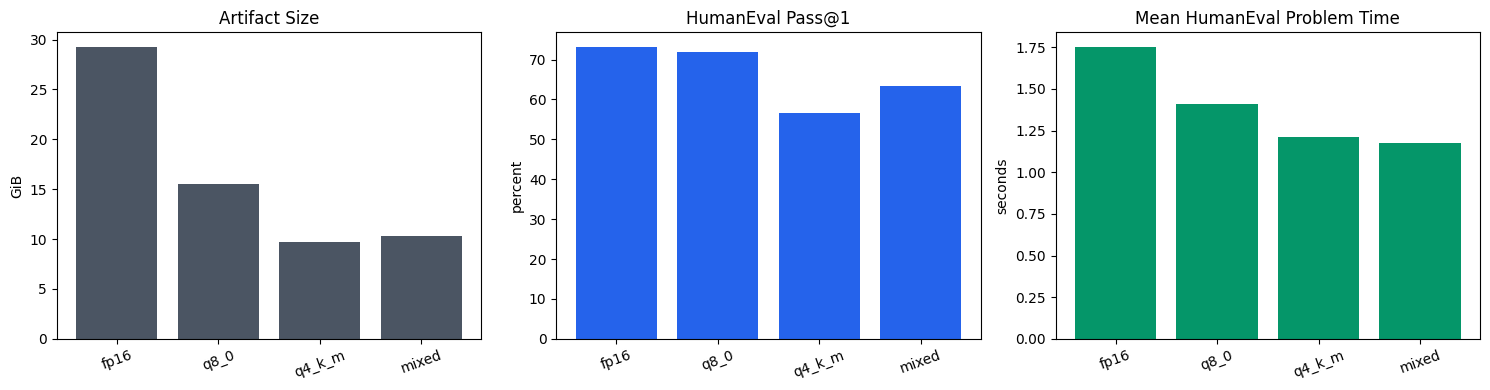

In [14]:
plot_rows = [row for row in joined_rows if row.get("pass_at_1_percent") is not None]
if plot_rows:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    labels = [row["model_key"] for row in plot_rows]

    axes[0].bar(labels, [row["size_gib"] for row in plot_rows], color="#4b5563")
    axes[0].set_title("Artifact Size")
    axes[0].set_ylabel("GiB")

    axes[1].bar(labels, [row["pass_at_1_percent"] for row in plot_rows], color="#2563eb")
    axes[1].set_title("HumanEval Pass@1")
    axes[1].set_ylabel("percent")

    axes[2].bar(labels, [row["mean_problem_sec"] for row in plot_rows], color="#059669")
    axes[2].set_title("Mean HumanEval Problem Time")
    axes[2].set_ylabel("seconds")

    for ax in axes:
        ax.tick_params(axis="x", rotation=20)

    plt.tight_layout()
    plt.show()
else:
    print("No completed GGUF HumanEval runs available yet for plots.")

## 11. Save Comparison Artifact

In [57]:
validation09["comparison"] = {
    "quality_rows": quality_rows,
    "performance_rows": perf_rows,
    "combined_rows": joined_rows,
    "reference_notes": [
        "Notebook 07 PyTorch baseline is context only unless no GGUF FP16 quality run exists.",
        "For the strongest claim, compare mixed GGUF against FP16, Q8_0, and Q4_K_M GGUF runs from this notebook.",
        "Existing Notebook 06 and Notebook 08 performance snapshots are useful but not as clean as fresh same-session benchmarks.",
    ],
}
validation09["updated_at_utc"] = datetime.now(timezone.utc).isoformat()

if RUN_FULL_HUMANEVAL or RUN_FRESH_PERF_BENCHMARKS or VALIDATION09_PATH.exists():
    save_json(VALIDATION09_PATH, validation09)
else:
    print("No new run requested and no existing Notebook 09 artifact found; not writing a placeholder result file.")

Saved /Users/jarrett/dev/quantization-study/results/09_mixed_precision_validation.json


## 12. Iteration Ledger

Use this section to record each mixed-policy variant as a reproducible row in an append-only ledger.  It captures policy version, protected layers, tensor-type manifest hash, artifact hash, metrics, and deltas vs baselines and previous iteration.

In [58]:
# User-editable iteration metadata
ITERATION_ID = "mixed_v2_protect_1_3_6_8_10_11_14_26"
ITERATION_NOTES = "Increased the number of protected layers."
ITERATION_PROTECTED_LAYERS = [1, 3, 6, 8, 10, 11, 14, 26]
ITERATION_PROTECTED_PRECISION = "q8_0"
ITERATION_DEFAULT_PRECISION = "q4_k_m"
ITERATION_SOURCE_POLICY_PATH = str(POLICY08_PATH)
ITERATION_TENSOR_TYPES_PATH = str(RESULTS_DIR / "09_tensor_types_v2.txt")
ITERATION_ARTIFACT_PATH = "/Users/jarrett/dev/quantization-study/exports/DeepSeek-Coder-V2-Lite-Instruct-MIXED-v2-protect-01-03-06-08-10-11-14-26.gguf"


def latest_summary(model_key):
    run = validation09.get("humaneval_runs", {}).get(model_key)
    return run.get("summary") if run else None


def latest_perf_summary(model_key):
    run = validation09.get("performance_runs", {}).get(model_key)
    if run:
        return run.get("summary")

    # Fallback to comparison rows populated from older snapshots.
    row = next((r for r in validation09.get("comparison", {}).get("performance_rows", []) if r.get("model_key") == model_key), None)
    if row is None:
        return None
    return {
        "ttft_sec_mean": row.get("ttft_sec_mean"),
        "tokens_per_sec_mean": row.get("tokens_per_sec_mean"),
        "total_latency_sec_mean": row.get("total_latency_sec_mean"),
        "n_samples": row.get("n_samples"),
    }


def delta(a, b):
    if a is None or b is None:
        return None
    return a - b


mixed_q = latest_summary("mixed")
fp16_q = latest_summary("fp16")
q8_q = latest_summary("q8_0")
q4_q = latest_summary("q4_k_m")

mixed_p = latest_perf_summary("mixed")
fp16_p = latest_perf_summary("fp16")
q8_p = latest_perf_summary("q8_0")
q4_p = latest_perf_summary("q4_k_m")

iteration_row = {
    "timestamp_utc": datetime.now(timezone.utc).isoformat(),
    "iteration_id": ITERATION_ID,
    "notes": ITERATION_NOTES,
    "policy": {
        "protected_layers": ITERATION_PROTECTED_LAYERS,
        "protected_precision": ITERATION_PROTECTED_PRECISION,
        "default_precision": ITERATION_DEFAULT_PRECISION,
        "source_policy_path": ITERATION_SOURCE_POLICY_PATH,
    },
    "files": {
        "tensor_types_path": ITERATION_TENSOR_TYPES_PATH,
        "tensor_types_sha256": sha256_file(ITERATION_TENSOR_TYPES_PATH),
        "artifact_path": ITERATION_ARTIFACT_PATH,
        "artifact_sha256": sha256_file(ITERATION_ARTIFACT_PATH),
        "artifact_size_gib": path_size_gib(ITERATION_ARTIFACT_PATH),
    },
    "metrics": {
        "humaneval": {
            "mixed_pass_at_1_percent": mixed_q.get("pass_at_1_percent") if mixed_q else None,
            "mixed_passed": f"{mixed_q['n_passed']}/{mixed_q['n_total']}" if mixed_q else None,
            "mixed_runtime_min_total": mixed_q.get("runtime_min_total") if mixed_q else None,
            "mixed_mean_problem_sec": mixed_q.get("problem_total_sec_mean") if mixed_q else None,
            "delta_pass_vs_fp16": delta(mixed_q.get("pass_at_1_percent") if mixed_q else None, fp16_q.get("pass_at_1_percent") if fp16_q else None),
            "delta_pass_vs_q8": delta(mixed_q.get("pass_at_1_percent") if mixed_q else None, q8_q.get("pass_at_1_percent") if q8_q else None),
            "delta_pass_vs_q4": delta(mixed_q.get("pass_at_1_percent") if mixed_q else None, q4_q.get("pass_at_1_percent") if q4_q else None),
        },
        "performance": {
            "mixed_tps": mixed_p.get("tokens_per_sec_mean") if mixed_p else None,
            "mixed_ttft_sec": mixed_p.get("ttft_sec_mean") if mixed_p else None,
            "mixed_latency_sec": mixed_p.get("total_latency_sec_mean") if mixed_p else None,
            "delta_tps_vs_fp16": delta(mixed_p.get("tokens_per_sec_mean") if mixed_p else None, fp16_p.get("tokens_per_sec_mean") if fp16_p else None),
            "delta_tps_vs_q8": delta(mixed_p.get("tokens_per_sec_mean") if mixed_p else None, q8_p.get("tokens_per_sec_mean") if q8_p else None),
            "delta_tps_vs_q4": delta(mixed_p.get("tokens_per_sec_mean") if mixed_p else None, q4_p.get("tokens_per_sec_mean") if q4_p else None),
            "delta_latency_vs_fp16": delta(mixed_p.get("total_latency_sec_mean") if mixed_p else None, fp16_p.get("total_latency_sec_mean") if fp16_p else None),
            "delta_latency_vs_q8": delta(mixed_p.get("total_latency_sec_mean") if mixed_p else None, q8_p.get("total_latency_sec_mean") if q8_p else None),
            "delta_latency_vs_q4": delta(mixed_p.get("total_latency_sec_mean") if mixed_p else None, q4_p.get("total_latency_sec_mean") if q4_p else None),
        },
    },
}

ledger_rows = read_jsonl(ITER_LEDGER_JSONL_PATH)
prior = ledger_rows[-1] if ledger_rows else None

if prior:
    prior_q = prior.get("metrics", {}).get("humaneval", {}).get("mixed_pass_at_1_percent")
    prior_tps = prior.get("metrics", {}).get("performance", {}).get("mixed_tps")
    prior_size = prior.get("files", {}).get("artifact_size_gib")
else:
    prior_q = prior_tps = prior_size = None

iteration_row["deltas_vs_previous_iteration"] = {
    "previous_iteration_id": prior.get("iteration_id") if prior else None,
    "delta_mixed_pass_at_1_percent": delta(iteration_row["metrics"]["humaneval"]["mixed_pass_at_1_percent"], prior_q),
    "delta_mixed_tps": delta(iteration_row["metrics"]["performance"]["mixed_tps"], prior_tps),
    "delta_artifact_size_gib": delta(iteration_row["files"]["artifact_size_gib"], prior_size),
}

preview = {
    "iteration_id": iteration_row["iteration_id"],
    "protected_layers": iteration_row["policy"]["protected_layers"],
    "mixed_pass_at_1_percent": iteration_row["metrics"]["humaneval"]["mixed_pass_at_1_percent"],
    "delta_pass_vs_q4": iteration_row["metrics"]["humaneval"]["delta_pass_vs_q4"],
    "mixed_tps": iteration_row["metrics"]["performance"]["mixed_tps"],
    "delta_tps_vs_q4": iteration_row["metrics"]["performance"]["delta_tps_vs_q4"],
    "artifact_size_gib": iteration_row["files"]["artifact_size_gib"],
    "delta_size_vs_prev": iteration_row["deltas_vs_previous_iteration"]["delta_artifact_size_gib"],
}

display(Markdown(markdown_table([preview], [
    ("iteration_id", "Iteration ID"),
    ("protected_layers", "Protected layers"),
    ("mixed_pass_at_1_percent", "Mixed pass@1"),
    ("delta_pass_vs_q4", "Delta pass vs Q4"),
    ("mixed_tps", "Mixed tok/s"),
    ("delta_tps_vs_q4", "Delta tok/s vs Q4"),
    ("artifact_size_gib", "Artifact GiB"),
    ("delta_size_vs_prev", "Delta GiB vs prev"),
])))

if APPEND_ITERATION_LEDGER:
    # Save a per-iteration snapshot of tensor-type manifest when available.
    tensor_src = Path(ITERATION_TENSOR_TYPES_PATH)
    if tensor_src.exists():
        tensor_dst = ITER_TENSOR_TYPES_DIR / f"{ITERATION_ID}.txt"
        tensor_dst.write_text(tensor_src.read_text())
        iteration_row["files"]["tensor_types_snapshot_path"] = str(tensor_dst)

    append_jsonl(ITER_LEDGER_JSONL_PATH, iteration_row)
    print(f"Appended ledger row to {ITER_LEDGER_JSONL_PATH}")
else:
    print("Ledger not appended. Set APPEND_ITERATION_LEDGER=True to append this row.")


| Iteration ID | Protected layers | Mixed pass@1 | Delta pass vs Q4 | Mixed tok/s | Delta tok/s vs Q4 | Artifact GiB | Delta GiB vs prev |
| --- | --- | --- | --- | --- | --- | --- | --- |
| mixed_v2_protect_1_3_6_8_10_11_14_26 | 1, 3, 6, 8, 10, 11, 14, 26 | 66.46 | 9.76 | 104.53 | -23.24 | 11.33 | 0.00 |

Appended ledger row to /Users/jarrett/dev/quantization-study/results/09_iteration_ledger.jsonl


## 13. Iteration History

In [59]:
ledger_rows = read_jsonl(ITER_LEDGER_JSONL_PATH)

history_rows = []
for row in ledger_rows[-20:]:
    history_rows.append({
        "timestamp_utc": row.get("timestamp_utc"),
        "iteration_id": row.get("iteration_id"),
        "protected_layers": row.get("policy", {}).get("protected_layers"),
        "pass_at_1": row.get("metrics", {}).get("humaneval", {}).get("mixed_pass_at_1_percent"),
        "delta_vs_q4": row.get("metrics", {}).get("humaneval", {}).get("delta_pass_vs_q4"),
        "tok_s": row.get("metrics", {}).get("performance", {}).get("mixed_tps"),
        "artifact_gib": row.get("files", {}).get("artifact_size_gib"),
    })

display(Markdown(markdown_table(history_rows, [
    ("timestamp_utc", "Timestamp UTC"),
    ("iteration_id", "Iteration ID"),
    ("protected_layers", "Protected layers"),
    ("pass_at_1", "Mixed pass@1"),
    ("delta_vs_q4", "Delta pass vs Q4"),
    ("tok_s", "Mixed tok/s"),
    ("artifact_gib", "Artifact GiB"),
])))


| Timestamp UTC | Iteration ID | Protected layers | Mixed pass@1 | Delta pass vs Q4 | Mixed tok/s | Artifact GiB |
| --- | --- | --- | --- | --- | --- | --- |
| 2026-05-25T06:43:46.691585+00:00 | mixed_v1_protect_3_11_26 | 3, 11, 26 | 63.41 | 6.71 | 124.42 | 10.28 |
| 2026-05-25T07:15:44.629965+00:00 | mixed_v2_protect_1_3_6_8_10_11_14_26 | 1, 3, 6, 8, 10, 11, 14, 26 | 63.41 | 6.71 | 124.42 | 10.28 |
| 2026-05-25T07:26:52.871114+00:00 | mixed_v2_protect_1_3_6_8_10_11_14_26 | 1, 3, 6, 8, 10, 11, 14, 26 | 63.41 | 6.71 | 124.42 | 11.33 |
| 2026-05-25T10:02:40.754875+00:00 | mixed_v2_protect_1_3_6_8_10_11_14_26 | 1, 3, 6, 8, 10, 11, 14, 26 | 66.46 | 9.76 | 124.42 | 11.33 |
| 2026-05-25T12:19:05.651899+00:00 | mixed_v2_protect_1_3_6_8_10_11_14_26 | 1, 3, 6, 8, 10, 11, 14, 26 | 66.46 | 9.76 | 104.53 | 11.33 |

## 14. Interpretation

In [60]:
quality_by_model = {row["model_key"]: row for row in quality_rows}
mixed_quality = quality_by_model.get("mixed")
fp16_quality = quality_by_model.get("fp16")
q4_quality = quality_by_model.get("q4_k_m")
q8_quality = quality_by_model.get("q8_0")

lines = []
if mixed_quality and mixed_quality.get("status") == "complete":
    lines.append(
        f"Mixed GGUF pass@1: {mixed_quality['pass_at_1_percent']:.2f}% "
        f"({mixed_quality['passed']})."
    )
    if fp16_quality and fp16_quality.get("status") == "complete":
        delta = mixed_quality["pass_at_1_percent"] - fp16_quality["pass_at_1_percent"]
        lines.append(f"Delta vs GGUF FP16: {delta:.2f} points.")
    if q4_quality and q4_quality.get("status") == "complete":
        delta = mixed_quality["pass_at_1_percent"] - q4_quality["pass_at_1_percent"]
        lines.append(f"Delta vs Q4_K_M: {delta:.2f} points.")
    if q8_quality and q8_quality.get("status") == "complete":
        delta = mixed_quality["pass_at_1_percent"] - q8_quality["pass_at_1_percent"]
        lines.append(f"Delta vs Q8_0: {delta:.2f} points.")
else:
    lines.append("Mixed GGUF HumanEval has not been run yet.")

mixed_perf = next((row for row in perf_rows if row["model_key"] == "mixed"), None)
q4_perf = next((row for row in perf_rows if row["model_key"] == "q4_k_m"), None)
if mixed_perf and mixed_perf.get("tokens_per_sec_mean") is not None:
    lines.append(
        f"Mixed microbenchmark: {mixed_perf['tokens_per_sec_mean']:.2f} tok/s, "
        f"TTFT {mixed_perf['ttft_sec_mean']:.4f}s, latency {mixed_perf['total_latency_sec_mean']:.4f}s."
    )
    if q4_perf and q4_perf.get("tokens_per_sec_mean") is not None:
        ratio = safe_div(mixed_perf["tokens_per_sec_mean"], q4_perf["tokens_per_sec_mean"])
        if ratio is not None:
            lines.append(f"Mixed throughput vs Q4_K_M snapshot: {ratio:.2f}x.")

lines.append(
    "Go/no-go criterion: the mixed model should materially improve quality over Q4_K_M while retaining most of the Q4_K_M size advantage.  "
    "If it is slower than expected, prioritize full HumanEval quality first, then profile the protected Q8_0 tensor overhead."
)

display(Markdown("\n".join(f"- {line}" for line in lines)))

- Mixed GGUF pass@1: 66.46% (109/164).
- Delta vs GGUF FP16: -6.71 points.
- Delta vs Q4_K_M: 9.76 points.
- Delta vs Q8_0: -5.49 points.
- Mixed microbenchmark: 104.53 tok/s, TTFT 0.0581s, latency 1.2892s.
- Mixed throughput vs Q4_K_M snapshot: 0.82x.
- Go/no-go criterion: the mixed model should materially improve quality over Q4_K_M while retaining most of the Q4_K_M size advantage.  If it is slower than expected, prioritize full HumanEval quality first, then profile the protected Q8_0 tensor overhead.